In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from lib import *

# Analyse des caractéristiques du réseau en tant que graphe

#### Chargement des données depuis le fichier de trace

Nous transformons chaque point GPS en objet puis pour chaque instant.
Ensuite, nous imposons une portée d'antenne statique et calculons les voisins de chaque satellite à chaque instant.

Objet Satellite:
- name -> str
- list_coordinates -> list\[InstantSatellite\]

Objet InstantSatellite:
- point -> Point (3D)
- neighbors -> list\[Satellite\]


In [2]:
data = load_data("./traces.csv")
ranges = [("20km", 20_000), ("40km", 40_000), ("60km", 60_000)]

satellites = {key: struct_data(data, static_range=range_as_meters) for key, range_as_meters in ranges}

Chargement des satellites imposant une portée statique uniforme de 20000m (20.0km)
100 satellites ont été chargés
Temps écoulé : 17.55 secondes

Chargement des satellites imposant une portée statique uniforme de 40000m (40.0km)
100 satellites ont été chargés
Temps écoulé : 21.58 secondes

Chargement des satellites imposant une portée statique uniforme de 60000m (60.0km)
100 satellites ont été chargés
Temps écoulé : 28.60 secondes



In [3]:
each_range_each_instant = partial(run_for_each_range_each_instant, data, satellites)
each_range_each_instant_on_data = partial(run_for_each_range_each_instant_on_calculated_data, data, satellites)

In [4]:
print("Chargement des nombres de satellites inatteignables par instant")
nb_unreachable_satellites_by_instant = each_range_each_instant(func=count_unreachable_satellites)
print("Chargement des valeurs de Fielder par instant")
fielder_value_by_instant = each_range_each_instant(func=fielder_value)
print("Chargement des sous-graphes par instant")
subgraphs_by_instant = each_range_each_instant(func=isolate_subgraphs)
print("Chargement des nombres de sous-graphes par instant")
nb_subgraphs_by_instant = each_range_each_instant_on_data(func=count_isolated_subgraphs, calculated_data=subgraphs_by_instant)

Chargement des nombres de satellites inatteignables par instant
Temps écoulé : 0.31 secondes

Chargement des valeurs de Fielder par instant
Temps écoulé : 39.55 secondes

Chargement des sous-graphes par instant
Temps écoulé : 72.04 secondes

Chargement des nombres de sous-graphes par instant
Temps écoulé : 0.00 secondes



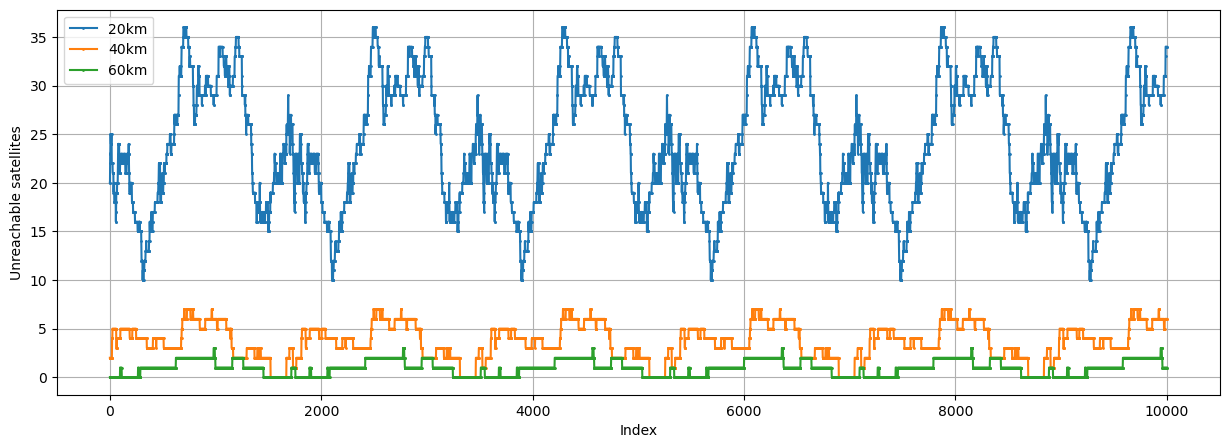

In [5]:
df = pd.DataFrame(nb_unreachable_satellites_by_instant)
df.plot(marker='o', markersize=1, figsize=(15, 5))

plt.xlabel("Index")
plt.ylabel("Unreachable satellites")
plt.grid(True)
plt.show()

In [6]:
len(subgraphs_by_instant["20km"][2])

27

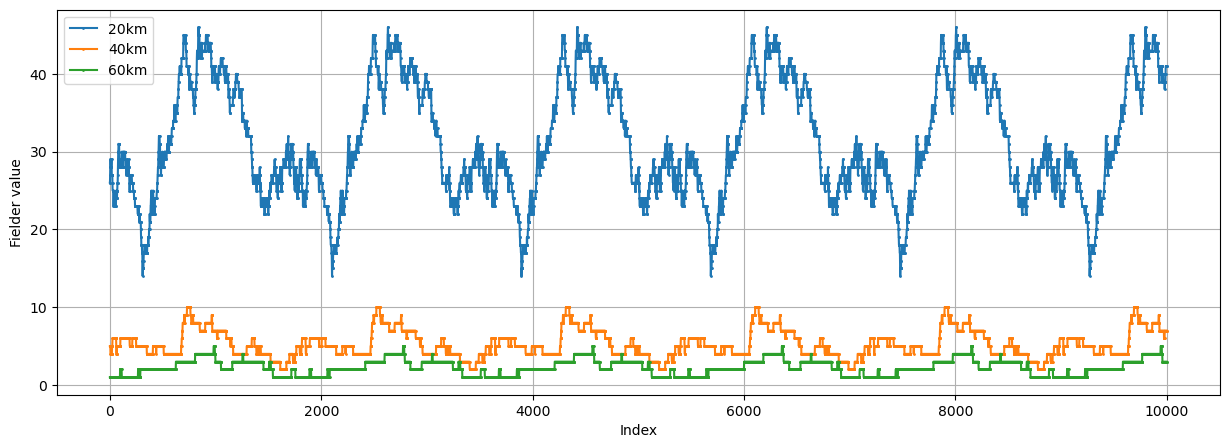

In [7]:
df = pd.DataFrame(nb_subgraphs_by_instant)
df.plot(marker='o', markersize=1, figsize=(15, 5))

plt.xlabel("Index")
plt.ylabel("Fielder value")
plt.grid(True)
plt.show()

In [9]:
def count_isolated_clusters(sats: list[Satellite], i: int, precalculated_subgraphs_instants: list[list[Satellite]]):
    lengths = np.array([len(subgraph) for subgraph in precalculated_subgraphs_instants[i]])
    return np.sum(lengths > 1)
    
nb_isolated_clusters = each_range_each_instant_on_data(func=count_isolated_clusters, calculated_data=subgraphs_by_instant)

Temps écoulé : 0.17 secondes



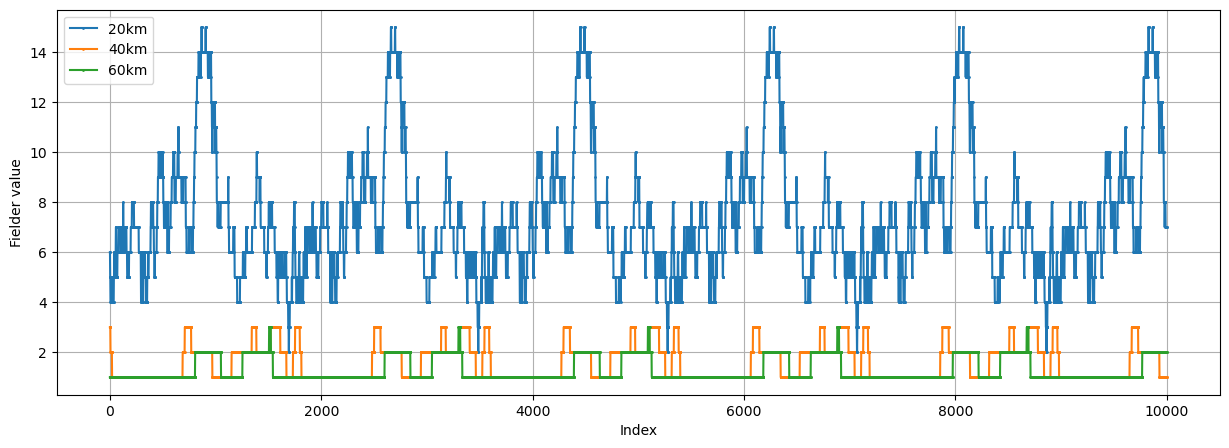

In [11]:
df = pd.DataFrame(nb_isolated_clusters)
df.plot(marker='o', markersize=1, figsize=(15, 5))

plt.xlabel("Index")
plt.ylabel("Fielder value")
plt.grid(True)
plt.show()